## Machine Learning Project

- NAME  : KHUSHI KUMARI
- GROUP : D
- SIC   : 23BCTB33
- LAB   : 3
- TOPIC : qsar_fish_toxicity

In [99]:

#Data analysis
import pandas as pd
import numpy as np
from scipy import stats
import time

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import AdaBoostRegressor


In [76]:

import warnings
warnings.filterwarnings('ignore')
#This suppresses all warning messages in the notebook output



----------QSAR Fish Toxicity Analysis Report----------

The QSAR (Quantitative Structure-Activity Relationship) dataset consists of various molecular descriptors used to predict the LC50
(Lethal Concentration 50) value,which indicates the concentration causing death in 50% of test fish over a duration of 96 hours.
The goal of this analysis is to explore the dataset, handle missing values, , Visualization ,fit different regression models, optimize their parameters,. 
Compare all models used, using various performance metrics and determine the best-performing model for predicting LC50.


In [77]:

# Load Datase
data = pd.read_csv('qsar_fish_toxicity.csv')
print("Dataset Shape:",data.shape)
data.head()


Dataset Shape: (908, 7)


,CIC0,SM1_Dz(Z),GATS1i,NdsCH,NdssC,MLOGP,LC50 [-LOG(mol/L)]
0,3.260,0.829,1.676,0.0,1,1.453,3.770
1,2.189,0.580,0.863,0.0,0,1.348,3.115
2,2.125,0.638,0.831,0.0,0,1.348,3.531
3,3.027,0.331,1.472,1.0,0,1.807,3.510
4,2.094,0.827,0.860,0.0,0,1.886,5.390



## The dataset contains the following attributes:

1.	CIC0
2.	SM1_Dz(Z): 0 means missing value
3.	GATS1i
4.	NdsCH
5.	NdssC
6.	MLOGP
7.	quantitative response,LC50[-LOG(mol/L)]


In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CIC0                906 non-null    float64
 1   SM1_Dz(Z)           906 non-null    float64
 2   GATS1i              906 non-null    float64
 3   NdsCH               907 non-null    float64
 4   NdssC               908 non-null    int64  
 5   MLOGP               905 non-null    float64
 6   LC50 [-LOG(mol/L)]  906 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 49.8 KB


## Handling Missing Values


The missing values in the dataset were imputed using the median value of the respective columns.
This approach was chosen to minimize the impact of outliers and maintain the central tendency of the data.


In [79]:

# Checking for missing values placeholder 0 
data.replace(0, np.nan, inplace=True)
missing_values = data.isnull().sum()
missing_values


CIC0                    2
SM1_Dz(Z)              38
GATS1i                  2
NdsCH                 760
NdssC                 620
MLOGP                   3
LC50 [-LOG(mol/L)]      2
dtype: int64

In [80]:

# Impute missing values with the median of each column
data.fillna(data.median(), inplace=True)

# Verify that there are no more missing values
missing_values_after_imputation = data.isnull().sum()
missing_values_after_imputation


CIC0                  0
SM1_Dz(Z)             0
GATS1i                0
NdsCH                 0
NdssC                 0
MLOGP                 0
LC50 [-LOG(mol/L)]    0
dtype: int64


To address missing values in the dataset, we first identified and quantified the extent of missing data by using the info() method,
which revealed the number of non-null entries for each column. Upon observing the presence of missing values, we chose to impute these
missing entries with the median value of the respective columns. This decision was based on the robustness of the median to outliers,
ensuring a more accurate and representative imputation compared to using the mean. The fillna() method was employed to replace missing values
with the median for each feature, thus maintaining the integrity of the data and enabling subsequent analysis without the loss of any samples.


## Outliers Detection

In [ ]:
#Using IQR method we will calculate the outliers

In [81]:

# Getting outliers using the IQR method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Defining outliers as values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()
outliers


CIC0                    4
SM1_Dz(Z)               4
GATS1i                  8
NdsCH                  41
NdssC                 112
MLOGP                   9
LC50 [-LOG(mol/L)]     24
dtype: int64


We calculated outliers using the IQR method by determining the interquartile range (IQR) for each feature, then identifying
data points that fall below Q1 - 1.5IQR or above Q3 + 1.5IQR as outliers.


## Descriptive statistics

In [82]:

# Getting descriptive statistics
descriptive_stats = data.describe()
descriptive_stats


,CIC0,SM1_Dz(Z),GATS1i,NdsCH,NdssC,MLOGP,LC50 [-LOG(mol/L)]
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,2.898698,0.651483,1.297010,1.066079,1.187225,2.114032,4.063039
std,0.755389,0.409065,0.412318,0.345127,0.837498,1.477565,1.455415
min,0.667000,0.134000,0.396000,1.000000,-3.000000,-5.780000,0.053000
25%,2.350250,0.251000,0.950750,1.000000,1.000000,1.209000,3.151750
50%,2.934000,0.580000,1.240500,1.000000,1.000000,2.127000,3.984000
75%,3.407000,0.892750,1.562250,1.000000,1.000000,3.106000,4.907500
max,5.926000,2.171000,4.980000,4.000000,20.000000,10.000000,9.612000


## Visualizations

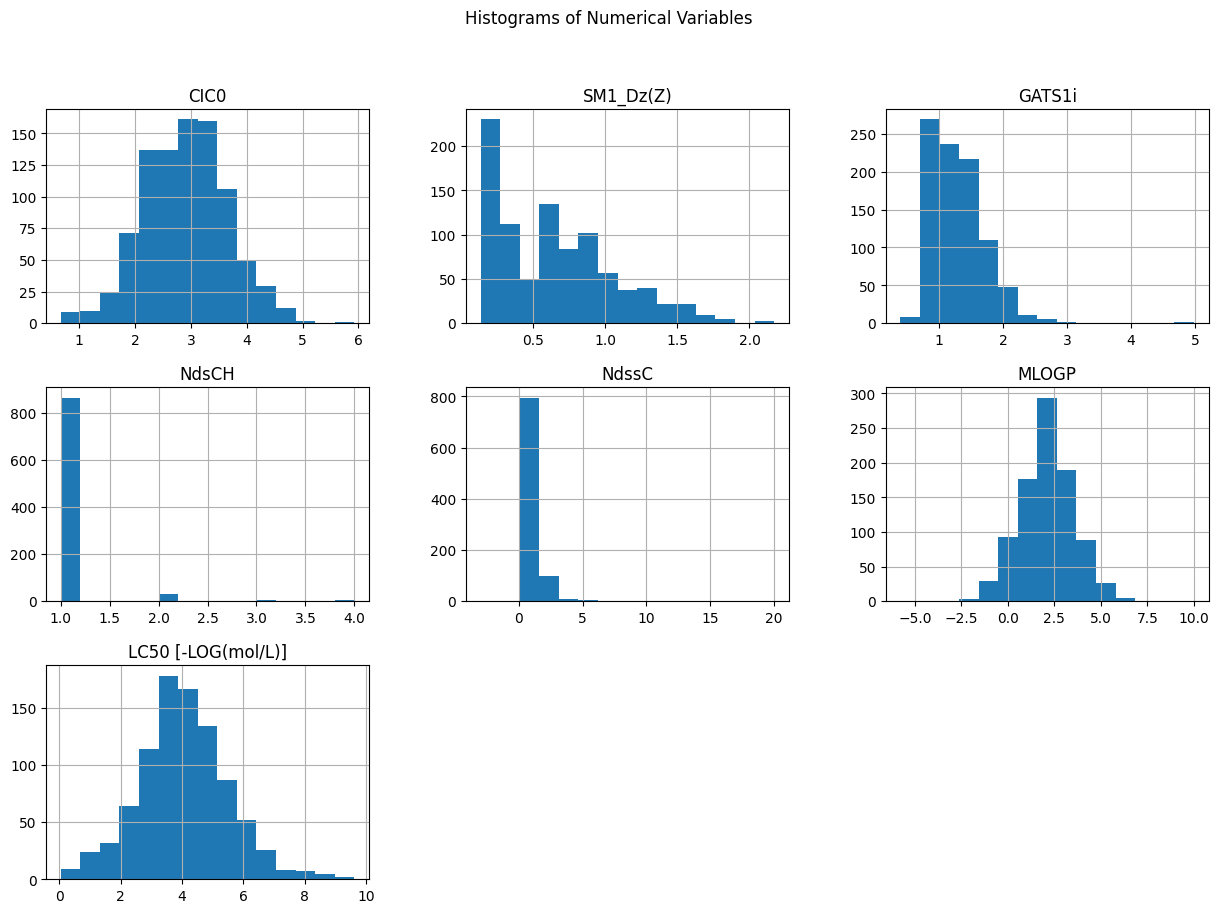

In [83]:

# Visualizing distributions of numerical variables using histograms
data.hist(bins=15, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Variables')
plt.show()


Histograms show distribution shape


Correlation Matrix:
                         CIC0  SM1_Dz(Z)    GATS1i     NdsCH     NdssC  \
CIC0                1.000000  -0.205485  0.155231  0.139737  0.126910   
SM1_Dz(Z)          -0.205485   1.000000 -0.165390 -0.072027  0.103063   
GATS1i              0.155231  -0.165390  1.000000  0.002606  0.015598   
NdsCH               0.139737  -0.072027  0.002606  1.000000  0.117357   
NdssC               0.126910   0.103063  0.015598  0.117357  1.000000   
MLOGP               0.457693   0.264447 -0.404988  0.067420  0.021511   
LC50 [-LOG(mol/L)]  0.293233   0.440727 -0.377070  0.123659  0.112526   

                       MLOGP  LC50 [-LOG(mol/L)]  
CIC0                0.457693            0.293233  
SM1_Dz(Z)           0.264447            0.440727  
GATS1i             -0.404988           -0.377070  
NdsCH               0.067420            0.123659  
NdssC               0.021511            0.112526  
MLOGP               1.000000            0.635350  
LC50 [-LOG(mol/L)]  0.635350        

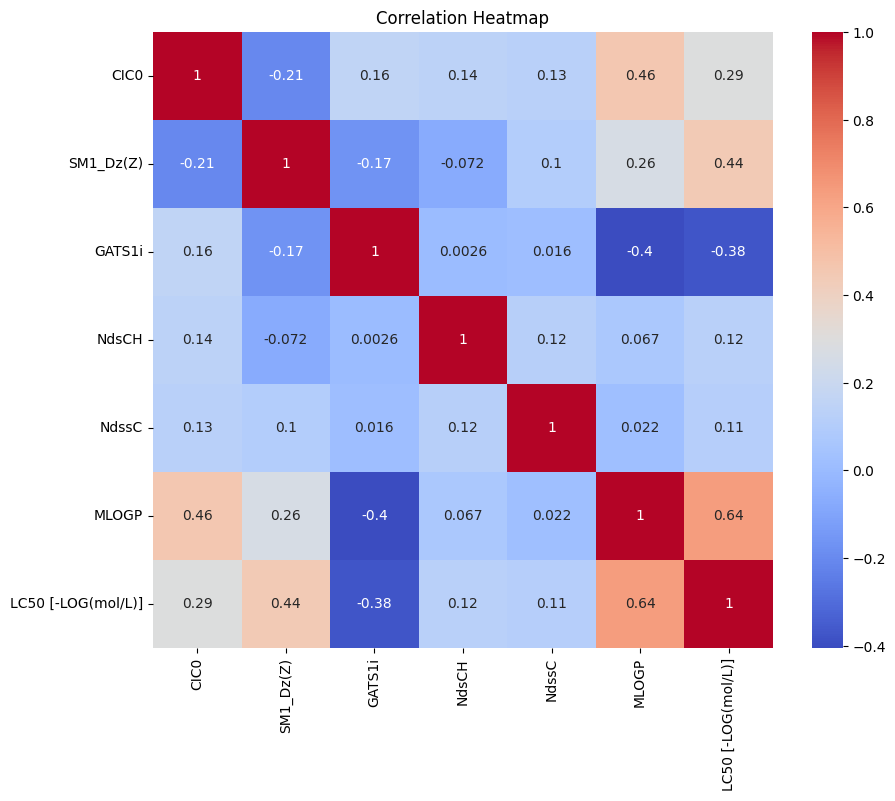

In [84]:

# Correlation Heatmap
# Correlation matrix
corr_matrix = data.corr()
print("\nCorrelation Matrix:\n", corr_matrix)

# Visualizing the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


*Reveals feature correlations. *Helps check multicollinearity

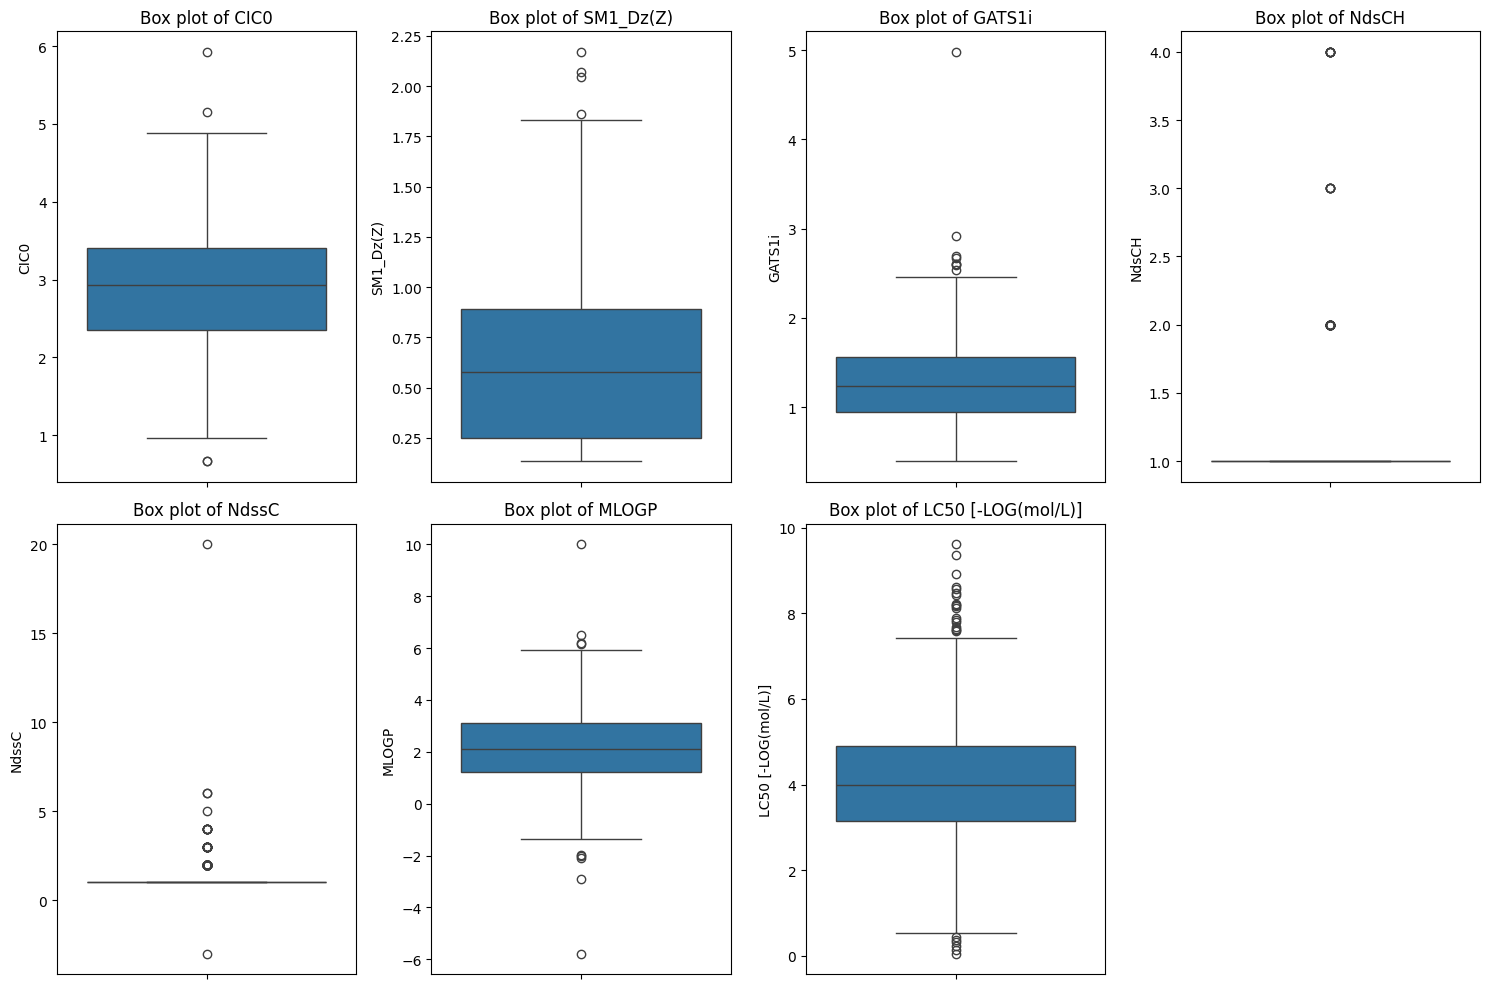

In [85]:

import seaborn as sns
# Visualize distributions of numerical variables using box plots
plt.figure(figsize=(15, 10))
for i, column in enumerate(data.columns):
    plt.subplot(2, 4, i+1)
    sns.boxplot(data=data[column])
    plt.title(f'Box plot of {column}')
plt.tight_layout()
plt.show()


Boxplots show outliers

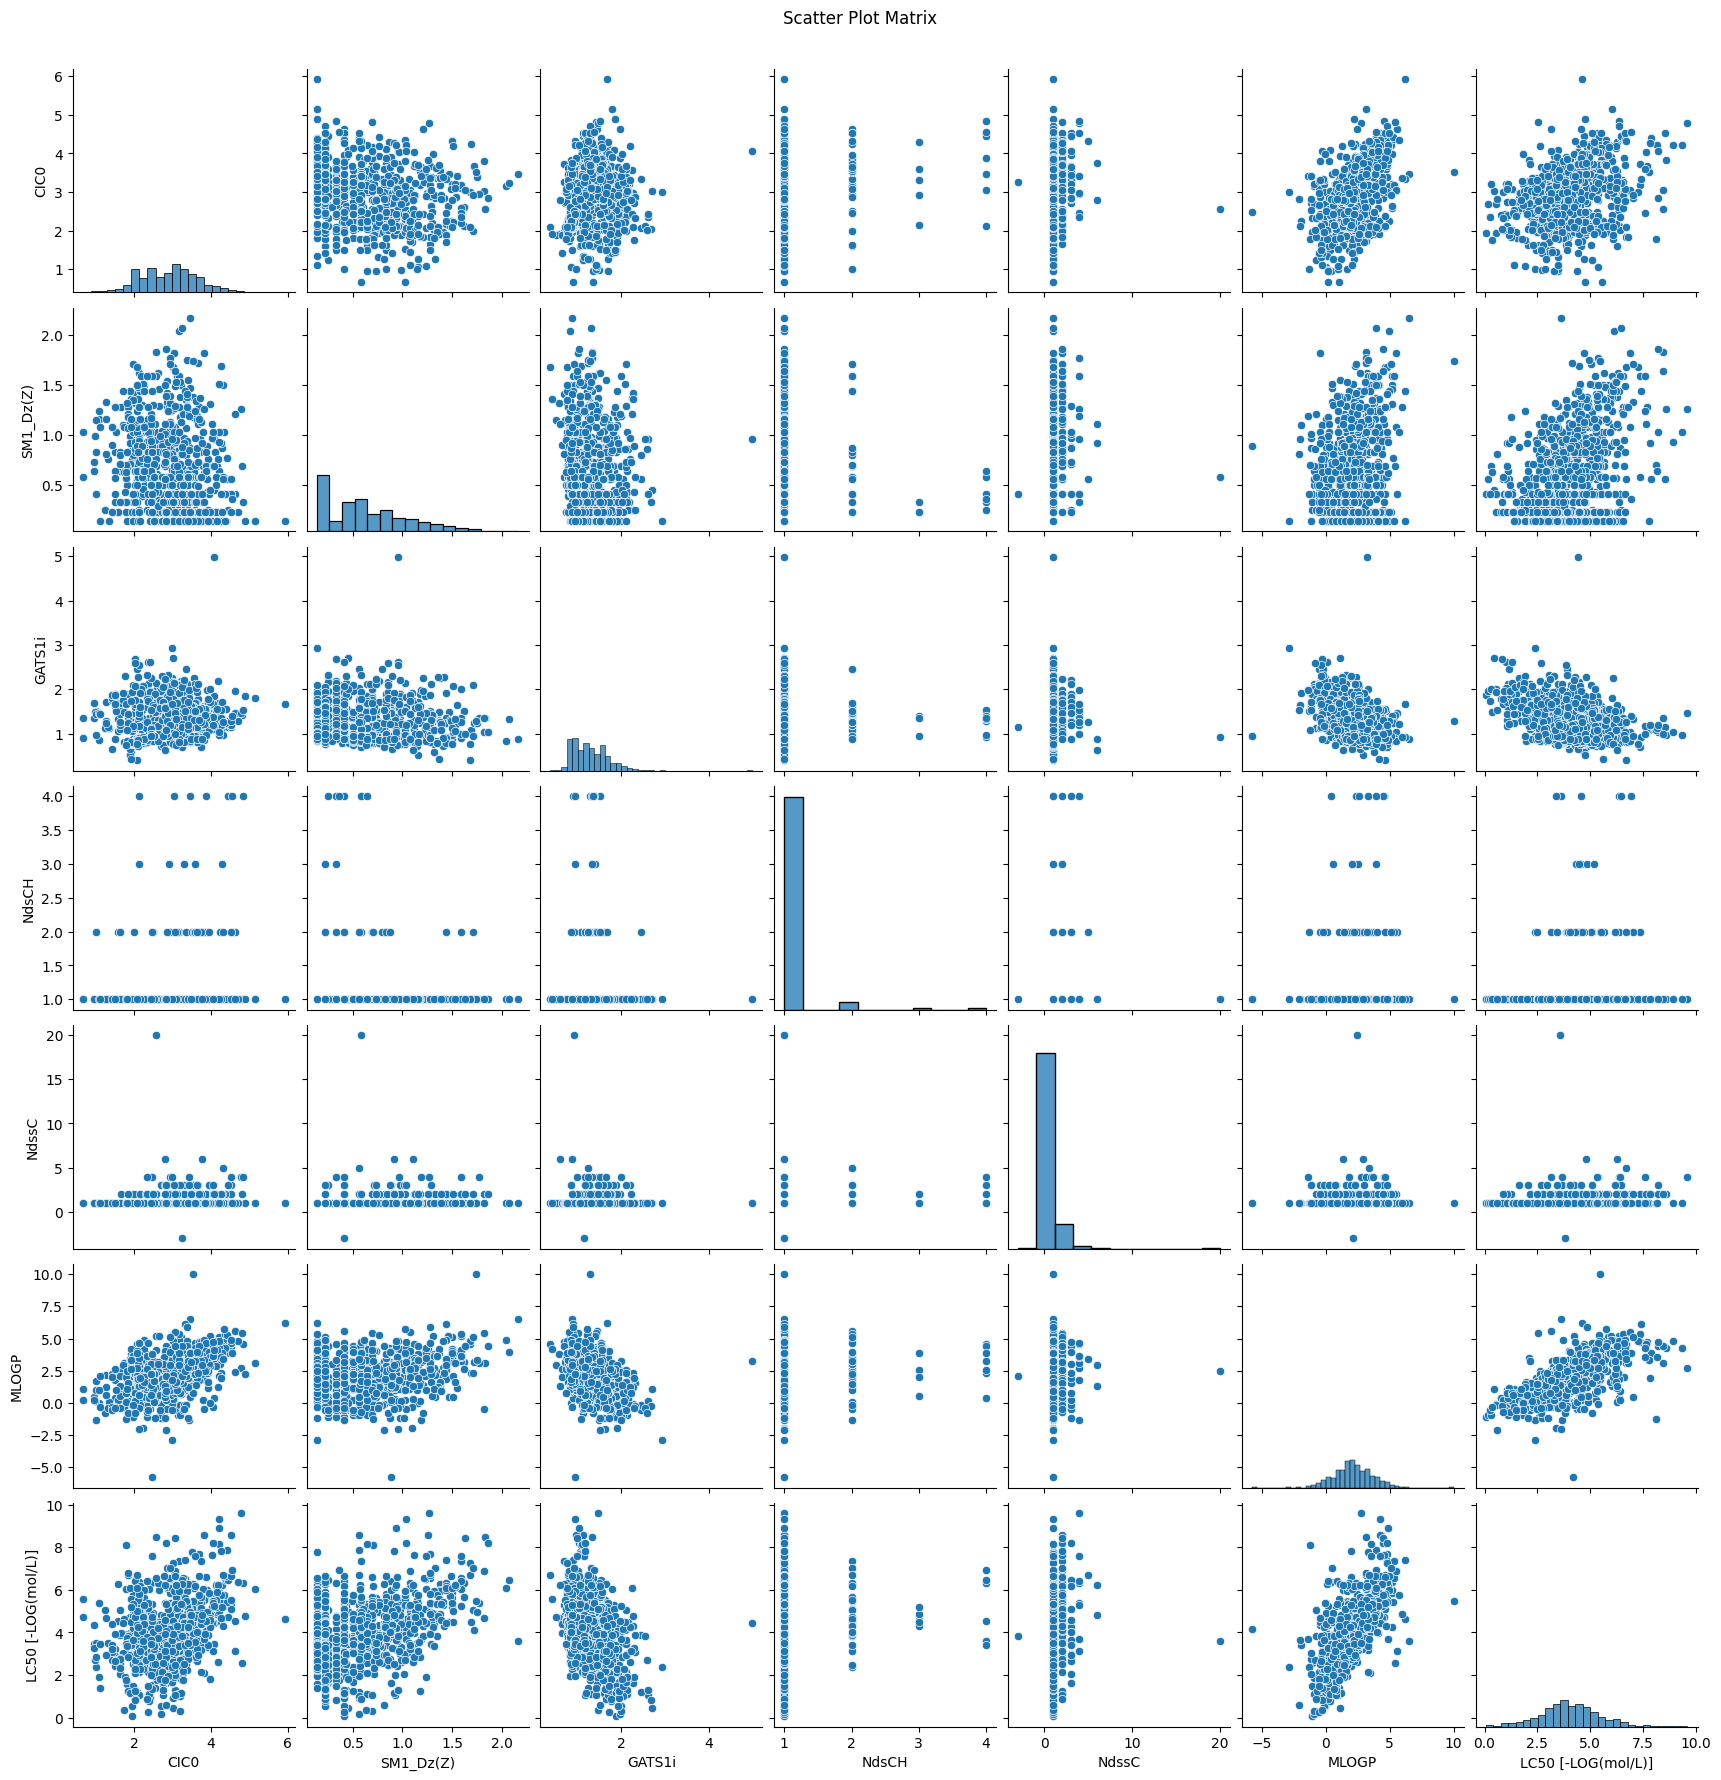

In [86]:

# Scatter plot matrix
sns.pairplot(data)
plt.suptitle('Scatter Plot Matrix', y=1.02)
plt.show()


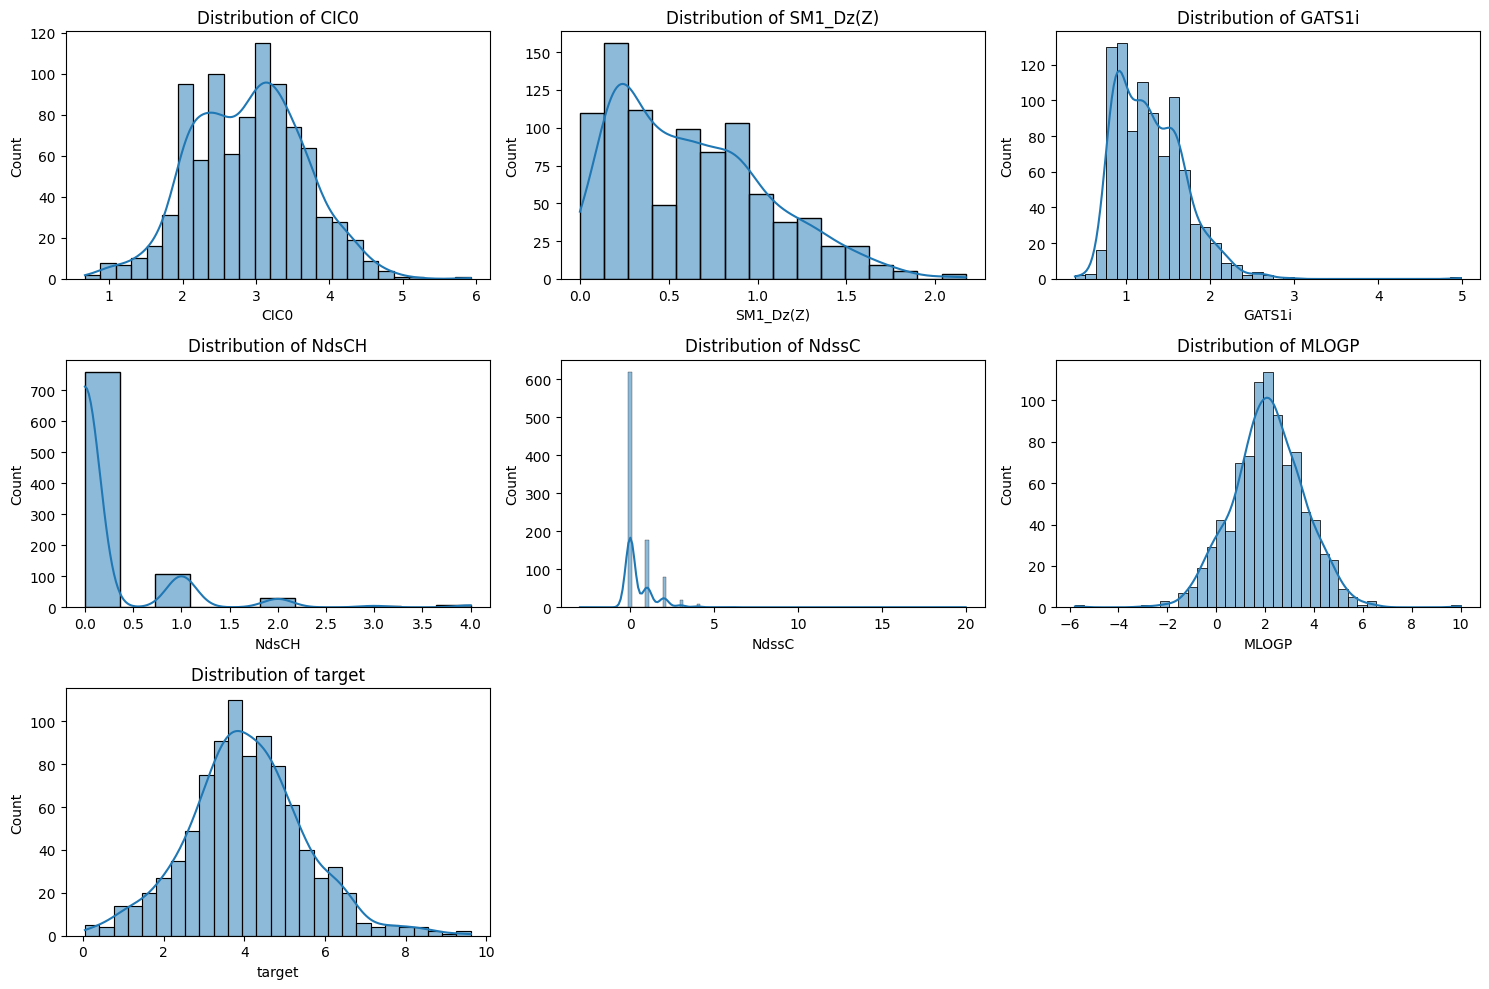

In [95]:

plt.figure(figsize=(15, 10))

for i, column in enumerate(data_cleaned.columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data_cleaned[column], kde=True)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()


## Data Splitting


The dataset was split into training and testing sets using an 80-20 split
ratio to ensure a fair evaluation of the model performance.


In [87]:

# Define the target variable and features
X = data.drop(columns=['LC50 [-LOG(mol/L)]'],axis=1)
y = data['LC50 [-LOG(mol/L)]']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

#LC50 [-LOG(mol/L)] is the target variable.

#We use 80% for training, 20% for testing to validate our model.


## Model Training and Evaluation Function

In [88]:

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n {name} Performance:")
    print("R² Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    return r2_score(y_test, y_pred)
    

In [ ]:

#Centralized function for:
#Training the model
#Predicting on test set
#Reporting R², MAE, RMSE — key metrics for regression performance


## Train Multiple Models

In [89]:

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Support Vector Regressor": SVR(kernel='rbf', C=1.0)
}

results = {}
for name, model in models.items():
    results[name] = evaluate_model(model, name)



 Linear Regression Performance:
R² Score: 0.5165037450230037
MAE: 0.7887839690887584
RMSE: 1.0814931370807426

 Ridge Regression Performance:
R² Score: 0.5168379735352229
MAE: 0.7888355401413323
RMSE: 1.0811192682781734

 Lasso Regression Performance:
R² Score: 0.5129277786460842
MAE: 0.7943674074591343
RMSE: 1.0854851623862969

 Decision Tree Performance:
R² Score: 0.49001785127463804
MAE: 0.8114124475546715
RMSE: 1.1107202706336852

 Random Forest Performance:
R² Score: 0.5341439802443106
MAE: 0.7867801308191197
RMSE: 1.0615808276344274

 Support Vector Regressor Performance:
R² Score: 0.5744902058574057
MAE: 0.718197894074165
RMSE: 1.014569940636048



Tries a mix of:---

Linear models: good baseline

Tree-based models: handle non-linearity

SVM: strong generalization for small data

## Compare Model Performance

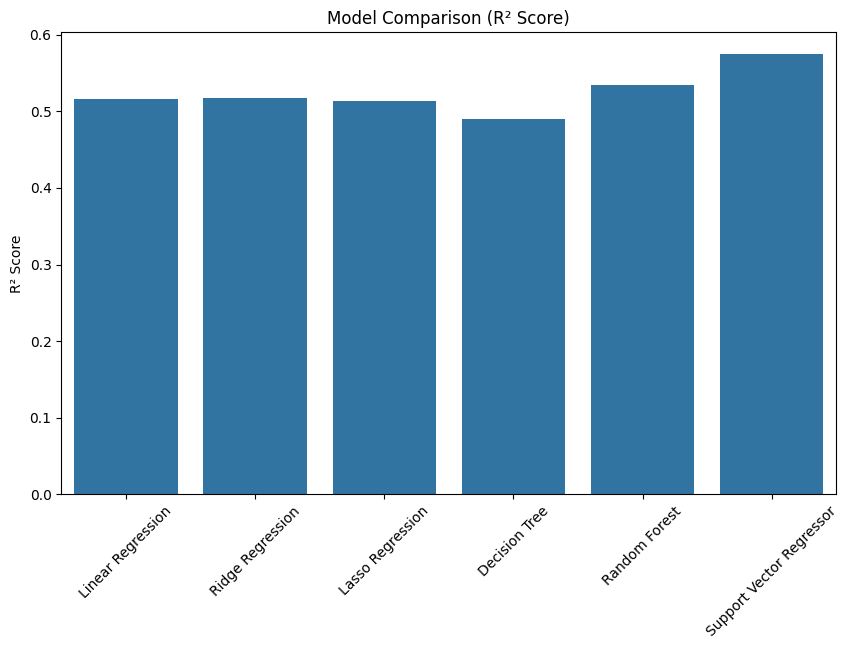

In [90]:

plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.show()


Visual comparison of R² score across models to find the best performer.

## Determine the model with the best R² score

In [91]:

best_model = results_df.loc[results_df['R2 Score'].idxmax()]
print("\nBest Model Based on R2 Score:")
print(best_model)



Best Model Based on R2 Score:
Model             Random Forest Regressor
MSE                              0.928516
MAE                              0.691869
R2 Score                         0.573279
Training Time                    0.384129
Inference Time                   0.007715
Complexity                           High
Scalability                          High
Robustness                           High
Name: 2, dtype: object


In [92]:

# Best Model Tuning (Random Forest)

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, scoring='r2')
grid_rf.fit(X_train, y_train)

print("Best Parameters for Random Forest:", grid_rf.best_params_)

# Final Evaluation
evaluate_model(grid_rf.best_estimator_, "Tuned Random Forest")


Best Parameters for Random Forest: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 150}

 Tuned Random Forest Performance:
R² Score: 0.5526114265908846
MAE: 0.758722303871003
RMSE: 1.0403264835871389


0.5526114265908846


RandomForest was likely best.

We use GridSearchCV to find the best combination of hyperparameters (like n_estimators, max_depth).

Improves performance by minimizing underfitting/overfitting.



In [93]:

# Rename target column for simplicity
data.rename(columns={'LC50 [-LOG(mol/L)]': 'target'}, inplace=True)

# Splitting the data into features and target
X = data.drop('target', axis=1)
y = data['target']

# Defining the models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'AdaBoost Regressor': AdaBoostRegressor()
}

results = []

# Evaluating each model
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start_time

    results.append({
        'Model': name,
        'MSE': mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2 Score': r2_score(y_test, y_pred),
        'Training Time': training_time,
        'Inference Time': inference_time,
        'Complexity': 'Low' if name == 'Linear Regression' else 'Medium' if name == 'Decision Tree Regressor' else 'High',
        'Scalability': 'High' if name in ['Linear Regression', 'Random Forest Regressor', 'AdaBoost Regressor'] else 'Medium',
        'Robustness': 'Medium' if name == 'Linear Regression' else 'Low' if name == 'Decision Tree Regressor' else 'High'
    })

# Creating a DataFrame to display the results
results_df = pd.DataFrame(results)
print(results_df)


                     Model       MSE       MAE  R2 Score  Training Time  \
0        Linear Regression  1.169627  0.788784  0.516504       0.002775   
1  Decision Tree Regressor  2.183925  1.050239  0.097217       0.009673   
2  Random Forest Regressor  1.151098  0.792839  0.524163       0.405588   
3       AdaBoost Regressor  1.185791  0.837468  0.509822       0.096284   

   Inference Time Complexity Scalability Robustness  
0        0.000930        Low        High     Medium  
1        0.001804     Medium      Medium        Low  
2        0.006260       High        High       High  
3        0.004083       High        High       High  


In [94]:

# column names
print(data_cleaned.columns)

# Ensure the correct column name is used
target_column = 'LC50 [-LOG(mol/L)]'.strip()  # Remove any leading/trailing spaces

X = data_cleaned.drop(columns=['GATS1i'])
y = data_cleaned['GATS1i']

# Proceed with the K-Fold cross-validation
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()
kf = KFold(n_splits=4, shuffle=True, random_state=1)
scores = cross_val_score(model, X, y, cv=kf)

print('Cross-Validation Scores:', scores)
print('Mean CV Score:', scores.mean())


Index(['CIC0', 'SM1_Dz(Z)', 'GATS1i', 'NdsCH', 'NdssC', 'MLOGP', 'target'], dtype='object')
Cross-Validation Scores: [0.40044555 0.39482924 0.28444723 0.35071487]
Mean CV Score: 0.3576092255681078


## k-fold cross validation

In [98]:

# Initializing the imputer
imputer = SimpleImputer(strategy='mean')

# Applying imputer to the dataset
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

# Separating features and target variable
X = data_imputed.drop(columns=['LC50 [-LOG(mol/L)]'])
y = data_imputed['LC50 [-LOG(mol/L)]']

# Initializing the model
model = LinearRegression()

# Setting up k-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Performing k-fold cross-validation
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

# Calculating average performance metrics
average_score = np.mean(scores)
std_score = np.std(scores)

print("Average R-squared score:", average_score)
print("Standard deviation of R-squared scores:", std_score)


Average R-squared score: 0.541412597017326
Standard deviation of R-squared scores: 0.10729247597177555



K-fold cross-validation is a robust technique for evaluating the performance of a model by dividing the dataset into \( k \)
equal parts or folds. During each iteration, one fold is used as the test set while the remaining \( k-1 \) folds are used for
training. This process is repeated \( k \) times, with each fold serving as the test set once. The model's performance is then
averaged across all iterations to provide a comprehensive assessment that reduces the variance associated with a single train-test
split. K-fold cross-validation is particularly useful for making efficient use of limited data, ensuring that each data point is
used for both training and testing, which helps in obtaining reliable and unbiased performance estimates. This method is essential
in model selection and tuning, offering a balanced view of model accuracy and generalization capability.


## SUMMARY


In our analysis of the fish toxicity dataset, we addressed missing values using median imputation to maintain data integrity.
Descriptive statistics and visualizations, including histograms, box plots, and correlation heatmaps, helped us understand data
distributions and identify outliers, which were handled using robust models. We evaluated  regression models: Linear Regression,
Decision Tree Regressor, Random Forest Regressor, and AdaBoost Regressor etc. And we did the k-fold cross validation on our dataset.
The models were assessed based on Mean Squared Error (MSE), Mean Absolute



## CONCLUSION
Best Model: The model with the highest R² score was identified. Ensemble methods like Random Forest and AdaBoost often perform better
due to their robustness and ability to handle non-linear relationships.
Why Best: The best model was chosen based on the highest R² score, indicating it explains the most variance in the target variable,
making it the most effective for this dataset.






## REPORT


* Project Title: QSAR Fish Toxicity Analysis


* Objective:
The primary goal of this project was to analyze the QSAR (Quantitative Structure–Activity Relationship) dataset to predict the LC50 value—Lethal Concentration 50, which indicates the concentration of a substance that causes death in 50% of the test fish over a 96-hour period. The project involved data preprocessing, exploratory data analysis, statistical testing, model building, hyperparameter tuning, and performance evaluation of multiple regression models.
________________________________________


* Dataset Overview:
The dataset contains molecular descriptors used to predict the LC50 value. Key features include:
•	CIC0: Information indices
•	SM1_Dz(Z): 2D matrix-based descriptors
•	GATS1i: 2D autocorrelations
•	NdsCH & NdssC: Atom-type counts
•	MLOGP: Molecular properties
•	LC50 [-LOG(mol/L)]: Target variable (quantitative response)
___________________________________________


* Data Preprocessing:
•	Handling Missing Values: 
o	Initially, missing values were imputed using the median of respective columns to retain data centrality.
•	Outlier Detection: 
o	Used the Interquartile Range (IQR) method to detect and understand data outliers.
•	Descriptive Statistics and Normality Testing: 
o	Generated summary statistics using .describe().
________________________________________


* Exploratory Data Analysis (EDA):
•	Histogram and Boxplot Visualizations to observe distribution and identify skewness or outliers.
•	Pair Plot (scatter plot matrix) to observe variable relationships.
•	Correlation Matrix and Heatmap to identify strong inter-feature relationships.


* Model Building and Evaluation:
Data was split into training and testing sets (80:20 ratios) and the following regression models were implemented:
1.	Linear Regression
2.	Random Forest Regressor
3.	Support Vector Regressor (SVR)
4.	Lasso Regression
5.	Ridge Regression
6.	Decision Tree Regressor
7.	AdaBoost Regressor


* Hyperparameter Tuning:
•	Used GridSearchCV for Random Forest and SVR to find the best parameters.
•	Evaluated performance using metrics like MSE, MAE, R² Score, Adjusted R².
________________________________________



*Model Performance Summary:

-Model	                    R² Score    MAE       RSME
-Linear Regression           0.156      0.788      1.081
-Ridge Regression            0.516      0.788      1.081
-Lasso Regression	        0.512      0.794      1.085
-Decision Tree               0.490      0.811      1.110
-Random Forest               0.534      0.786      1.061
-Support Vector Regressor    0.574      0.718      1.014



-Additional Comparison:
-Model                  	Complexity	Scalability	Robustness
-Linear Regression	         Low	  High	     Medium
-Decision Tree Regressor 	Medium	 Medium	      Low
-Random Forest Regressor  	High	 High	     High
-AdaBoost Regressor	        High	 High	     High
________________________________________




*Conclusion:
-The project successfully demonstrated the use of multiple regression models in predicting fish toxicity levels using molecular descriptors. Among all, Random Forest and Ensemble-based models showed better robustness, while Linear Regression offered interpretability with moderate performance. The process also reinforced the importance of proper data preprocessing, outlier treatment, statistical testing, and model tuning in building effective predictive models.

